<a href="https://colab.research.google.com/github/RaMarWilson1/GenAI/blob/main/Hw3/Problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

--2024-12-18 00:49:17--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  22.5MB/s    in 9.1s    

2024-12-18 00:49:26 (19.0 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

--2024-12-18 00:49:26--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat’

test_32x32.mat      100%[===================>]  61.30M  19.1MB/s    in 4.1s    

2024-12-18 00:49:30 (15.0 MB/s) - ‘test_32x32.mat’ saved [64275384/64

In [4]:
# Hyperparameters for VAE
IMAGE_SIZE = 32  # Common image size, SVHN uses 32x32
BATCH_SIZE = 64  # A moderate batch size for stability and performance
VALIDATION_SPLIT = 0.2  # 20% of the data used for validation
EMBEDDING_DIM = 2  # Latent space dimensionality, 2 for visualization purposes
EPOCHS = 200  # More epochs
BETA = 10


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, datasets
import tensorflow.keras.backend as K

In [6]:
from scipy.io import loadmat

# Load data
train_data = loadmat('train_32x32.mat')
test_data = loadmat('test_32x32.mat')

# Preprocess the data
x_train = np.transpose(train_data['X'], (3, 0, 1, 2)).astype('float32') / 255.0
y_train = train_data['y'].flatten()
x_test = np.transpose(test_data['X'], (3, 0, 1, 2)).astype('float32') / 255.0
y_test = test_data['y'].flatten()

# Display the shape of the datasets
print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')



Training data shape: (73257, 32, 32, 3)
Test data shape: (26032, 32, 32, 3)


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import backend as K
from tensorflow.keras import metrics, losses # Import metrics and losses

# Define IMAGE_SIZE and EMBEDDING_DIM
IMAGE_SIZE = 32  # Assuming your images are 32x32
EMBEDDING_DIM = 2 # Set to your desired embedding dimension

def sampling(args):
    z_mean, z_log_var = args
    # Use tf.shape within a Lambda layer for compatibility with Keras symbolic tensors
    batch = tf.keras.backend.shape(z_mean)[0]
    dim = tf.keras.backend.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_input = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="encoder_input"
)
x = layers.Conv2D(32, (3, 3), strides=2, activation="relu", padding="same")(
    encoder_input
)
x = layers.Conv2D(64, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(128, (3, 3), strides=2, activation="relu", padding="same")(x)
shape_before_flattening = K.int_shape(x)[1:]  # the decoder will need this!

x = layers.Flatten()(x)
z_mean = layers.Dense(EMBEDDING_DIM, name="z_mean")(x)
z_log_var = layers.Dense(EMBEDDING_DIM, name="z_log_var")(x)
# Change 'Sampling' to 'sampling' to match the function definition
z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = models.Model(encoder_input, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 16, 16, 32)           896       ['encoder_input[0][0]']       
                                                                                                  
 conv2d_1 (Conv2D)           (None, 8, 8, 64)             18496     ['conv2d[0][0]']              
                                                                                                  
 conv2d_2 (Conv2D)           (None, 4, 4, 128)            73856     ['conv2d_1[0][0]']            
                                                                                            

In [8]:
# Decoder

decoder_input = layers.Input(shape=(EMBEDDING_DIM,), name="decoder_input")
x = layers.Dense(np.prod(shape_before_flattening))(decoder_input)
x = layers.Reshape(shape_before_flattening)(x)
x = layers.Conv2DTranspose(
    128, (3, 3), strides=2, activation="relu", padding="same"
)(x)
x = layers.Conv2DTranspose(
    64, (3, 3), strides=2, activation="relu", padding="same"
)(x)
x = layers.Conv2DTranspose(
    32, (3, 3), strides=2, activation="relu", padding="same"
)(x)
decoder_output = layers.Conv2D(
    3,  # Changed from 1 to 3 to match the input channels
    (3, 3),
    strides=1,
    activation="sigmoid",
    padding="same",
    name="decoder_output",
)(x)

decoder = models.Model(decoder_input, decoder_output)
decoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 decoder_input (InputLayer)  [(None, 2)]               0         
                                                                 
 dense (Dense)               (None, 2048)              6144      
                                                                 
 reshape (Reshape)           (None, 4, 4, 128)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 8, 8, 128)         147584    
 anspose)                                                        
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 16, 16, 64)        73792     
 Transpose)                                                      
                                                                 
 conv2d_transpose_2 (Conv2D  (None, 32, 32, 32)        18464 

In [9]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        """Call the model on a particular input."""
        z_mean, z_log_var, z = encoder(inputs)
        reconstruction = decoder(z)
        return z_mean, z_log_var, reconstruction

    def train_step(self, data):
        """Step run during training."""
        with tf.GradientTape() as tape:
            z_mean, z_log_var, reconstruction = self(data)
            reconstruction_loss = tf.reduce_mean(
                BETA
                * losses.binary_crossentropy(
                    data, reconstruction, axis=(1, 2, 3)
                )
            )
            kl_loss = tf.reduce_mean(
                tf.reduce_sum(
                    -0.5
                    * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                    axis=1,
                )
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        """Step run during validation."""
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, reconstruction = self(data)
        reconstruction_loss = tf.reduce_mean(
            BETA
            * losses.binary_crossentropy(data, reconstruction, axis=(1, 2, 3))
        )
        kl_loss = tf.reduce_mean(
            tf.reduce_sum(
                -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                axis=1,
            )
        )
        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

In [16]:
vae = VAE(encoder, decoder)

In [17]:

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
vae.compile(optimizer=optimizer)

In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_callback = ModelCheckpoint(
    'vae_model',  # Path where the model will be saved
    save_best_only=True,  # Save only the best model
    monitor='val_loss',  # Monitor validation loss
    mode='min',  # We want the minimum loss
    verbose=1,  # Print messages when saving
     save_format='tf'
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,  # Stop training after 10 epochs with no improvement
    verbose=1  # Print messages when stopping
)

In [29]:
history = vae.fit(
    x_train,  # Use x_train instead of train_data
     epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),  # Validation data
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/200
1145/1145 [==============================] - ETA: 0s - total_loss: 6.8791 - reconstruction_loss: 6.8791 - kl_loss: 1.0554e-06
Epoch 1: val_loss improved from inf to 6.97091, saving model to vae_model


1145/1145 [==============================] - 314s 275ms/step - total_loss: 6.8791 - reconstruction_loss: 6.8791 - kl_loss: 1.0554e-06 - val_loss: 6.9709 - val_reconstruction_loss: 6.9709 - val_kl_loss: 3.0727e-06
Epoch 2/200
1145/1145 [==============================] - ETA: 0s - total_loss: 6.8792 - reconstruction_loss: 6.8792 - kl_loss: 1.1048e-06
Epoch 2: val_loss improved from 6.97091 to 6.95982, saving model to vae_model


1145/1145 [==============================] - 309s 270ms/step - total_loss: 6.8792 - reconstruction_loss: 6.8792 - kl_loss: 1.1048e-06 - val_loss: 6.9598 - val_reconstruction_loss: 6.9598 - val_kl_loss: 5.3272e-07
Epoch 3/200
1145/1145 [==============================] - ETA: 0s - total_loss: 6.8792 - reconstruction_loss: 6.8792 - kl_loss: 5.9003e-07
Epoch 3: val_loss did not improve from 6.95982
1145/1145 [==============================] - 315s 275ms/step - total_loss: 6.8792 - reconstruction_loss: 6.8792 - kl_loss: 5.9003e-07 - val_loss: 6.9731 - val_reconstruction_loss: 6.9731 - val_kl_loss: 1.5150e-06
Epoch 4/200
1145/1145 [==============================] - ETA: 0s - total_loss: 6.8791 - reconstruction_loss: 6.8791 - kl_loss: 5.7651e-07
Epoch 4: val_loss did not improve from 6.95982
1145/1145 [==============================] - 315s 276ms/step - total_loss: 6.8791 - reconstruction_loss: 6.8791 - kl_loss: 5.7651e-07 - val_loss: 6.9671 - val_reconstruction_loss: 6.9671 - val_kl_loss: 1.

In [32]:
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
from tensorflow.keras import metrics, losses
import numpy as np

# Define the loss function
def vae_loss(y_true, y_pred):
    """Custom loss function for the VAE."""
    reconstruction_loss = tf.reduce_mean(
        BETA
        * losses.binary_crossentropy(
            y_true, y_pred, axis=(1, 2, 3)
        )
    )

    # Get z_mean and z_log_var from the encoder output
    z_mean, z_log_var, z = encoder(y_true)

    kl_loss = tf.reduce_mean(
        tf.reduce_sum(
            -0.5
            * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
            axis=1,
        )
    )
    total_loss = reconstruction_loss + kl_loss
    return total_loss

# Load the model with the custom loss function
vae = load_model('vae_model', custom_objects={'vae_loss': vae_loss, 'sampling': sampling, "tf": tf, 'BETA': BETA})

In [33]:
from tensorflow.keras.models import load_model

vae = load_model('vae_model', custom_objects={'vae_loss': vae_loss})

In [36]:
history = vae.fit(
    train_data,
    epochs=188,  # Additional epochs to train
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[checkpoint_callback, early_stopping_callback]
)



ValueError: Failed to find data adapter that can handle input: (<class 'dict'> containing {"<class 'str'>"} keys and {"<class 'bytes'>", "<class 'str'>", "(<class 'list'> containing values of types set())", "<class 'numpy.ndarray'>"} values), <class 'NoneType'>

In [37]:
history = vae.fit(
    x_train,  # Use x_train instead of train_data
    epochs=188,  # Additional epochs to train
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/188


ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1152, in train_step
        self._validate_target_and_loss(y, loss)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1116, in _validate_target_and_loss
        raise ValueError(

    ValueError: No loss found. You may have forgotten to provide a `loss` argument in the `compile()` method.


In [38]:
# Select a subset of the test set
n_to_predict = 5000
example_images = x_test[:n_to_predict]
example_labels = y_test[:n_to_predict]

In [40]:
# Create autoencoder predictions and display
z_mean, z_log_var, reconstructions = vae.predict(example_images)
print("Example real clothing items")
display(example_images)
print("Reconstructions")
display(reconstructions)


157/157 [==============================] - 4s 26ms/step
Example real clothing items


array([[[[0.14901961, 0.40392157, 0.23529412],
         [0.15294118, 0.40784314, 0.23921569],
         [0.15294118, 0.40784314, 0.24313726],
         ...,
         [0.16078432, 0.4       , 0.23921569],
         [0.16470589, 0.40392157, 0.24313726],
         [0.15294118, 0.38039216, 0.22352941]],

        [[0.15294118, 0.40784314, 0.23921569],
         [0.15294118, 0.40784314, 0.23921569],
         [0.15294118, 0.40784314, 0.24313726],
         ...,
         [0.16078432, 0.4       , 0.23921569],
         [0.16862746, 0.39607844, 0.24705882],
         [0.15294118, 0.38039216, 0.22352941]],

        [[0.14901961, 0.4117647 , 0.24313726],
         [0.14509805, 0.40784314, 0.23921569],
         [0.15294118, 0.41568628, 0.24705882],
         ...,
         [0.16862746, 0.39607844, 0.24705882],
         [0.16862746, 0.39215687, 0.2509804 ],
         [0.15294118, 0.38039216, 0.23137255]],

        ...,

        [[0.20392157, 0.46666667, 0.30588236],
         [0.20784314, 0.47058824, 0.30980393]

Reconstructions


array([[[[0.457384  , 0.45415476, 0.46757075],
         [0.45604295, 0.45527652, 0.46901256],
         [0.4562617 , 0.45638356, 0.47011176],
         ...,
         [0.4544117 , 0.45352   , 0.4690831 ],
         [0.45173395, 0.45293093, 0.4676115 ],
         [0.45514354, 0.452095  , 0.46477437]],

        [[0.45412537, 0.4521375 , 0.46627945],
         [0.45408064, 0.45364723, 0.46908838],
         [0.45362076, 0.4543916 , 0.4705811 ],
         ...,
         [0.45046228, 0.452709  , 0.46990845],
         [0.4506068 , 0.45252854, 0.4675894 ],
         [0.45046386, 0.4490912 , 0.46555305]],

        [[0.45065886, 0.45099586, 0.46692124],
         [0.4514765 , 0.45154604, 0.46881473],
         [0.45064676, 0.45179874, 0.47053844],
         ...,
         [0.44784084, 0.4502999 , 0.4686345 ],
         [0.44767323, 0.44912824, 0.46609318],
         [0.44709262, 0.44528568, 0.46418846]],

        ...,

        [[0.44513038, 0.4470301 , 0.4660574 ],
         [0.44572634, 0.44714344, 0.46823522]

In [41]:
# Encode the example images
z_mean, z_var, z = encoder.predict(example_images)

157/157 [==============================] - 1s 6ms/step


In [42]:
# Some examples of the embeddings
print(z[:10])

[[-0.29185098 -0.5278149 ]
 [ 0.1316022   0.3797359 ]
 [ 1.7597697  -1.9534222 ]
 [ 0.53213817 -0.67573464]
 [-1.0324584  -0.2914634 ]
 [ 1.4245086  -0.84772533]
 [-0.7412142  -0.8708406 ]
 [ 0.00265986 -1.4581989 ]
 [-0.38849172 -0.24342935]
 [ 0.05544278 -0.9839092 ]]


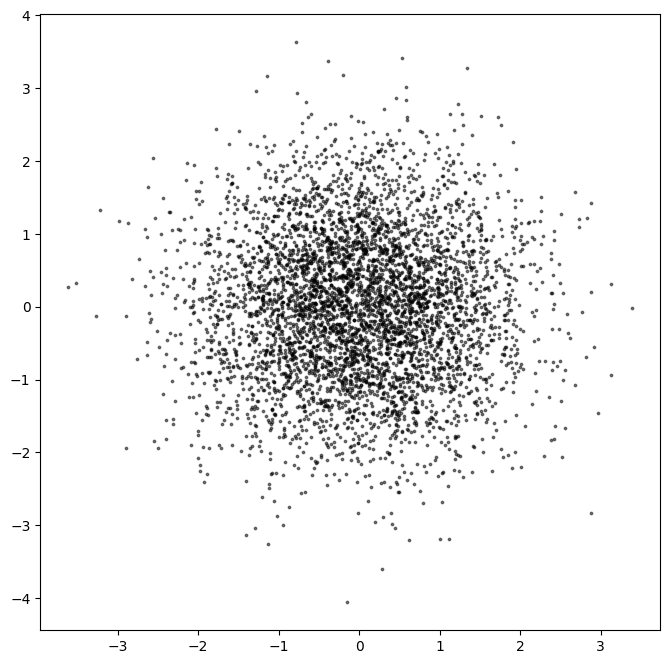

In [43]:
# Show the encoded points in 2D space
figsize = 8

plt.figure(figsize=(figsize, figsize))
plt.scatter(z[:, 0], z[:, 1], c="black", alpha=0.5, s=3)
plt.show()

In [44]:
# Sample some points in the latent space, from the standard normal distribution
grid_width, grid_height = (6, 3)
z_sample = np.random.normal(size=(grid_width * grid_height, 2))

In [45]:
# Decode the sampled points
reconstructions = decoder.predict(z_sample)

1/1 [==============================] - 0s 101ms/step


In [47]:
# Import the necessary module
from scipy.stats import norm

# Convert original embeddings and sampled embeddings to p-values
p = norm.cdf(z)
p_sample = norm.cdf(z_sample)

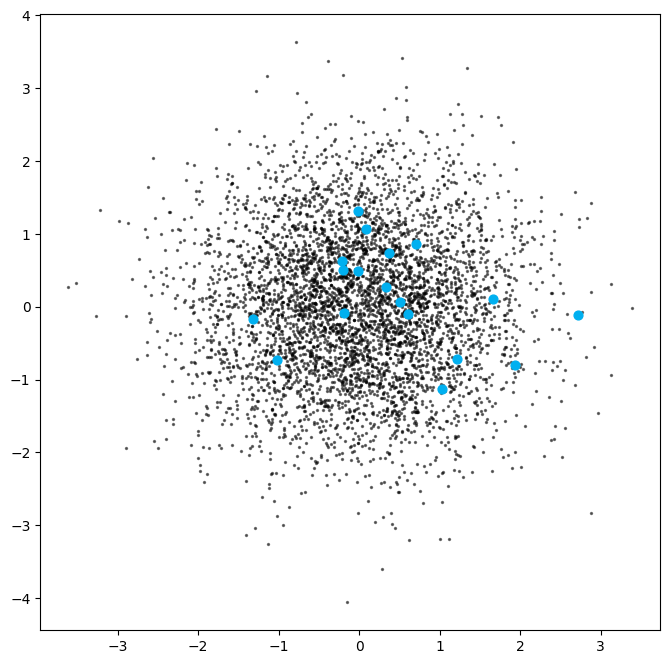

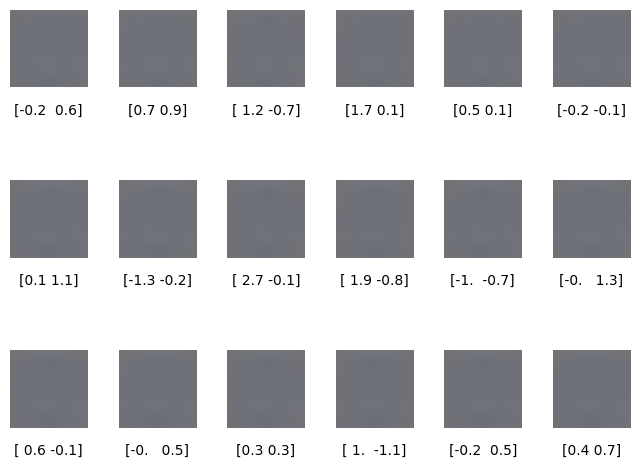

In [48]:
# Draw a plot of...
figsize = 8
plt.figure(figsize=(figsize, figsize))

# ... the original embeddings ...
plt.scatter(z[:, 0], z[:, 1], c="black", alpha=0.5, s=2)

# ... and the newly generated points in the latent space
plt.scatter(z_sample[:, 0], z_sample[:, 1], c="#00B0F0", alpha=1, s=40)
plt.show()

# Add underneath a grid of the decoded images
fig = plt.figure(figsize=(figsize, grid_height * 2))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.text(
        0.5,
        -0.35,
        str(np.round(z_sample[i, :], 1)),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.imshow(reconstructions[i, :, :], cmap="Greys")

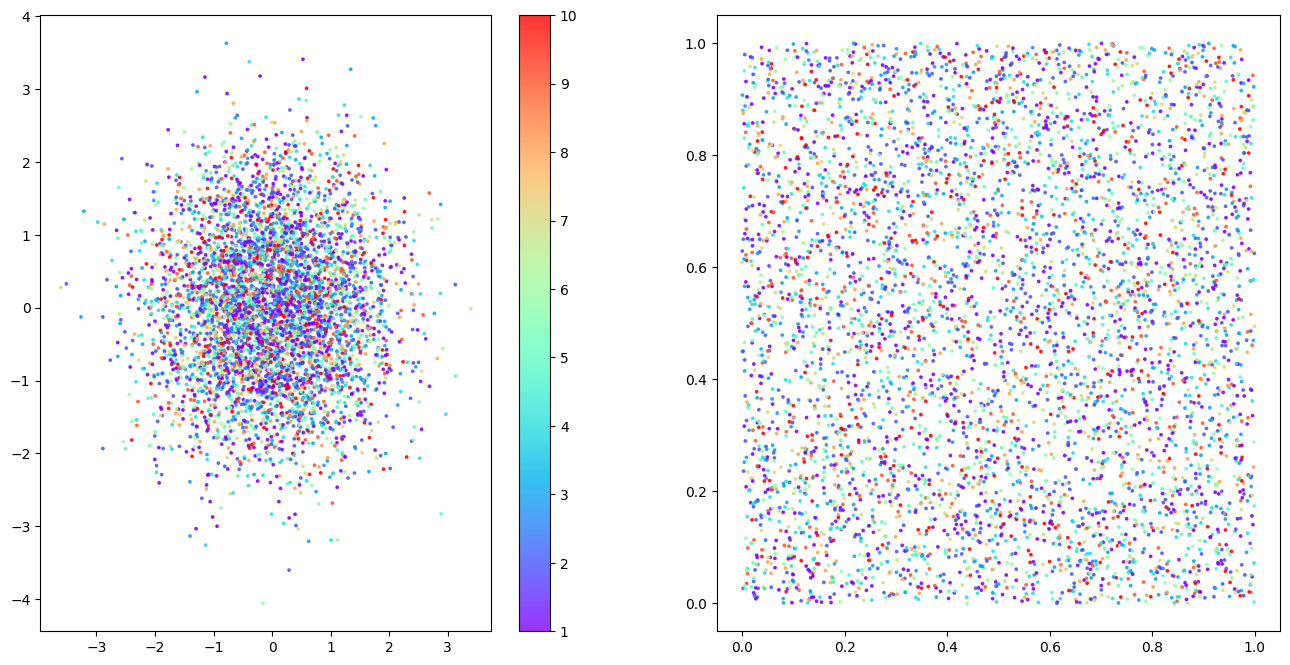

In [49]:
# Colour the embeddings by their label (clothing type - see table)
figsize = 8
fig = plt.figure(figsize=(figsize * 2, figsize))
ax = fig.add_subplot(1, 2, 1)
plot_1 = ax.scatter(
    z[:, 0], z[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=3
)
plt.colorbar(plot_1)
ax = fig.add_subplot(1, 2, 2)
plot_2 = ax.scatter(
    p[:, 0], p[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=3
)
plt.show()


8/8 [==============================] - 0s 11ms/step


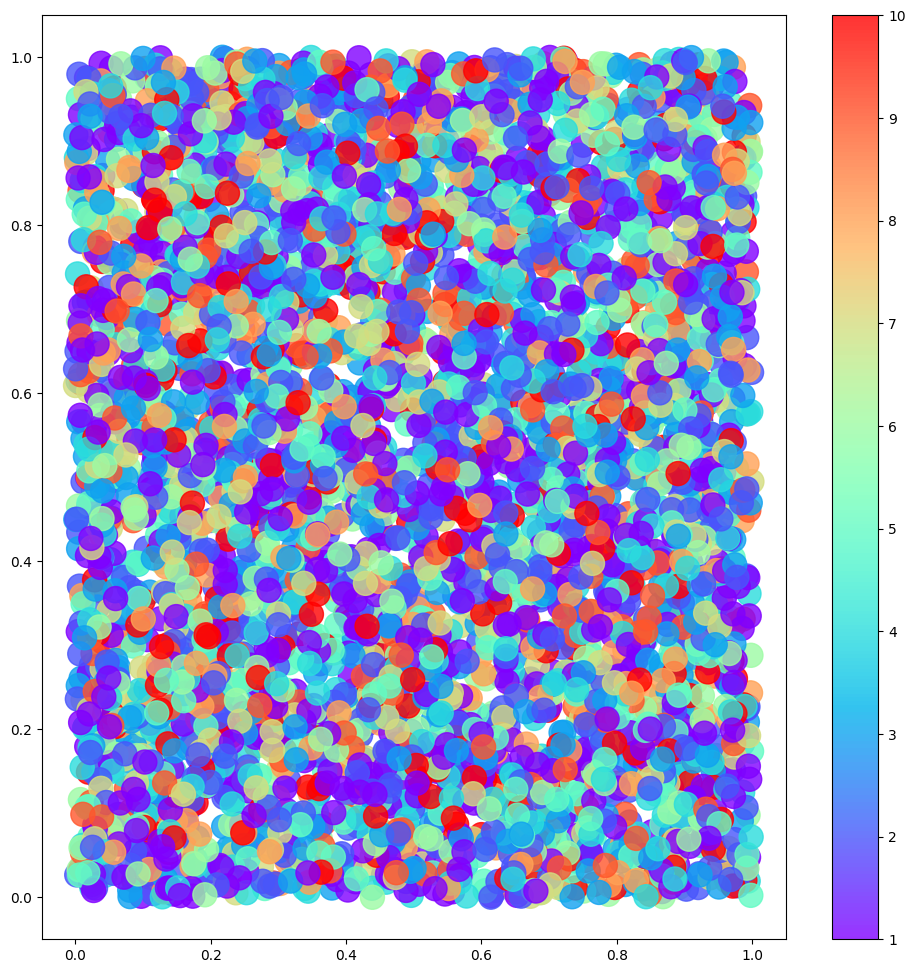

/usr/local/lib/python3.10/dist-packages/matplotlib/cm.py:489: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


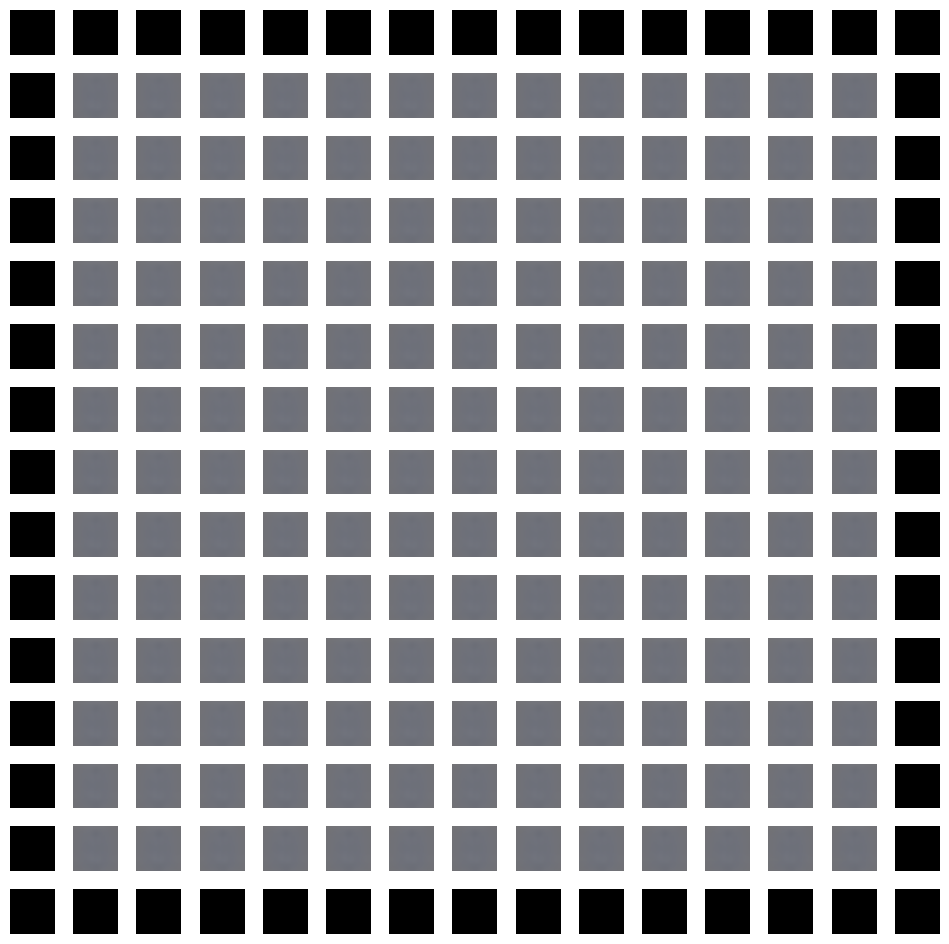

In [50]:
# Colour the embeddings by their label (clothing type - see table)
figsize = 12
grid_size = 15
plt.figure(figsize=(figsize, figsize))
plt.scatter(
    p[:, 0], p[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=300
)
plt.colorbar()

x = norm.ppf(np.linspace(0, 1, grid_size))
y = norm.ppf(np.linspace(1, 0, grid_size))
xv, yv = np.meshgrid(x, y)
xv = xv.flatten()
yv = yv.flatten()
grid = np.array(list(zip(xv, yv)))

reconstructions = decoder.predict(grid)
# plt.scatter(grid[:, 0], grid[:, 1], c="black", alpha=1, s=10)
plt.show()

fig = plt.figure(figsize=(figsize, figsize))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(grid_size**2):
    ax = fig.add_subplot(grid_size, grid_size, i + 1)
    ax.axis("off")
    ax.imshow(reconstructions[i, :, :], cmap="Greys")